In [1]:
import matplotlib.pyplot as plt
import numpy as np
from utils import ImageBatchGenerator,AnimalsDataset
from PIL import Image
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision 

c:\Users\ayhan\anaconda3\Lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: 'Could not find module 'C:\Users\ayhan\anaconda3\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


n_samples 653


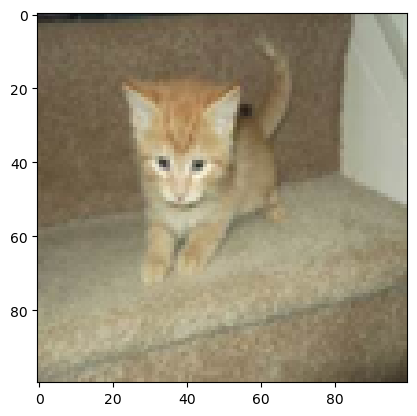

In [2]:
dogs_path = r"C:\Users\ayhan\Desktop\ml-collection\data\ten_animals\raw-img\dog"
cats_path = r"C:\Users\ayhan\Desktop\ml-collection\data\ten_animals\raw-img\cat"
batch_generator = ImageBatchGenerator({"dog":dogs_path, "cat":cats_path},batch_size=64,network_input_size=(100,100))
(val_batch,val_labels),(test_batch,test_labels) = batch_generator.return_val_test_batches()
plt.imshow(val_batch[:,:,:,0])

In [3]:
val_batch.shape, test_batch.shape

((100, 100, 3, 652), (100, 100, 3, 652))

In [4]:
batch_generator.batch_matrix.shape

(100, 100, 3, 652)

### now lets set our baseline model and get the baseline score 

In [6]:
# define the baseline CNN model
class BaselineCNN(nn.Module):
    def __init__(self,input_size:int,num_classes:int)->None:
        super(BaselineCNN,self).__init__()
        ...

    def forward(self,X):
        ... 

In [36]:
class AnimalsDataset(Dataset):
    def __init__(self, img_batch_generator: ImageBatchGenerator,transform = None):
        self.batch_generator = img_batch_generator
        self.all_img_paths = self.batch_generator.all_img_paths
        self.all_labels = self.batch_generator.all_labels
        self.invert_labels = self.batch_generator.invert_labels # inherit.
        if transform is None:
            self.transform = torchvision.transforms.Compose([
                torchvision.transforms.ToTensor(),
                torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # to align with ImageNet dataset for later transfer learning studies
            ])
        else:
            self.transform = torchvision.transforms.Compose([
                torchvision.transforms.ToTensor(),
                transform,
                torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self, idx):
        img_path = self.all_img_paths[idx]
        label = self.all_labels[idx]
        
        # use the prepare_batch method for a single image
        img = self.batch_generator.prepare_batch([img_path])
        img = img.squeeze(3)  # remove the batch dimension
        if self.transform:
            img = self.transform(img)
        
        return img, torch.tensor(label, dtype=torch.long)

In [37]:
# animal_dataset = AnimalsDataset(batch_generator,transform=torchvision.transforms.CenterCrop(10))
animal_dataset = AnimalsDataset(batch_generator)


### we implemented our ImageBatchGenerator in a way for it to be used both with and without AnimalDataset and DataLoader. 

In [38]:
dogs_path = r"C:\Users\ayhan\Desktop\ml-collection\data\ten_animals\raw-img\dog"
cats_path = r"C:\Users\ayhan\Desktop\ml-collection\data\ten_animals\raw-img\cat"
batch_generator = ImageBatchGenerator({"dog": dogs_path, "cat": cats_path}, batch_size=128, network_input_size=(100, 100))

dataloader = DataLoader(animal_dataset, batch_size=32, shuffle=True)

for epoch in range(1):
    for batch_images, batch_labels in dataloader:
        print(batch_images.shape, batch_labels.shape)
        print(batch_labels)
        print(dataloader.dataset.invert_labels(batch_labels))
        break
    break

n_samples 653
torch.Size([32, 3, 100, 100]) torch.Size([32])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 0])
['dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog'
 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog'
 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog']


In [39]:
batch_images[0].shape

torch.Size([3, 100, 100])

In [12]:
for i,val in enumerate(batch_generator):
    print(val["labels"])
    break

iter called
next called
['cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'dog' 'cat' 'cat'
 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat' 'dog'
 'dog' 'cat' 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'dog'
 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'cat' 'cat' 'dog' 'dog' 'dog'
 'cat' 'dog' 'cat' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'cat' 'dog'
 'cat' 'cat' 'cat' 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'cat' 'cat' 'cat'
 'dog' 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat'
 'dog' 'dog' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'dog' 'cat' 'cat'
 'dog' 'cat' 'dog' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat' 'cat' 'cat' 'dog'
 'dog' 'cat' 'cat' 'dog' 'cat' 'cat' 'cat' 'dog' 'dog' 'dog' 'dog' 'dog'
 'dog' 'cat' 'dog' 'dog' 'cat' 'dog' 'dog' 'cat']


### train-val-test split enabler Dataset and Dataloader 

In [ ]:
dogs_path = r"C:\Users\ayhan\Desktop\ml-collection\data\ten_animals\raw-img\dog"
cats_path = r"C:\Users\ayhan\Desktop\ml-collection\data\ten_animals\raw-img\cat"
batch_generator = ImageBatchGenerator({"dog": dogs_path, "cat": cats_path}, batch_size=64, network_input_size=(224, 224))

val_batch, test_batch = batch_generator.return_val_test_batches()
train_dataset = AnimalsDataset(batch_generator)
val_dataset = AnimalsDataset(batch_generator, img_paths=batch_generator.val_img_paths, labels=batch_generator.val_labels)
test_dataset = AnimalsDataset(batch_generator, img_paths=batch_generator.test_img_paths, labels=batch_generator.test_labels)
# Create dataloaders
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
